Сначала просто импорт пандаса и загрузка исходного датасета

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np

In [46]:
start_data = pd.read_excel('NetflixShows.xlsx')

In [47]:
data = start_data

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1000 non-null   object 
 1   rating             1000 non-null   object 
 2   ratingLevel        941 non-null    object 
 3   ratingDescription  1000 non-null   int64  
 4   release year       1000 non-null   int64  
 5   user rating score  605 non-null    float64
 6   user rating size   1000 non-null   int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB


Что находится в этом датасете:

0. title - название фильма/сериала
1. rating - рейтинг (ограничение) на категорию лиц, для которых предназначен фильм (например, не предназначен для лиц 17 лет и младше), который обозначен своим "кодом" (например, TV-MA и тд)
2. ratingLevel - Описание рейтинга словами (буквально словами написано на английском "не предназначен для лиц 17 лет и младше" и тд)
3. ratingDescription - числа, сопоставленные рейтингу которые как-то связаны (личное наблюдение) с жесткостью огграничений (например, у доступного всем возрастам, это 10, а у 18+ - 110)
4. release year - год релиза
5. user rating score - интересная темка, кто-то воспринимает ее как просто рейтинг фильма, но на самом деле на офиц сайте нетфликс сказано, что это персональный предикт от нетфликса, который в процентах предполагает, насколько фильм соответствует интересам конкретного юзера, основываясь на его прошлых предпочтениях, а не какая-то общая стата
6. user rating size - принимает 3 значения: 80 - если рейтинг скор есть, 81 и 82 - если нет (дата собиралась из разных источников, так что 81 и 82 - могут быть просто разные кодировки)





Из инфо видим, что пропуски у нас в двух полях:
1. ratingLevel - в целом нам не слишком нужен этот столбец, тк там просто словесное описание, мы не будем проводить с ним исследования, так что его мы просто дропнем.
2. user rating score - cохраним еuj отдельно (вместе с названиями в качестве ключей, чтобы потом удобно было сливать) до поры, до времени, а из этого датасета удалим, пока чистим данные.

еще бесполезным столбцом является user rating size, потому что проверить наличие рейтинг скора мы можем легко и так, поэтому его тоже кик

Удаляем 3 столбца, которые обсудили выше

In [49]:
user_rating_score = data[['title', 'user rating score']]

In [50]:
data = data.drop(columns=['ratingLevel', 'user rating score', 'user rating size'])

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              1000 non-null   object
 1   rating             1000 non-null   object
 2   ratingDescription  1000 non-null   int64 
 3   release year       1000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 31.4+ KB


дропнем пропуски

In [52]:
data = data.dropna()

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              1000 non-null   object
 1   rating             1000 non-null   object
 2   ratingDescription  1000 non-null   int64 
 3   release year       1000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 31.4+ KB


Со всеми пропусками и неподходящими значениями разобрались, дропнем дубликаты и получим чистенькие данные

In [54]:
data = data.drop_duplicates('title')

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 496 entries, 0 to 998
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              496 non-null    object
 1   rating             496 non-null    object
 2   ratingDescription  496 non-null    int64 
 3   release year       496 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 19.4+ KB


Ураааа, 496 чистеньких столбца, но только вот из них мы мало что можем понять, тк тут у нас только "возрастная категория" фильма из инфы

Добавим прекраснейшие датасеты с рейтингом имдб 🙏

In [56]:
imdb_ratings = pd.read_csv('title.ratings.tsv', sep='\t')

In [57]:
imdb_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1619877 entries, 0 to 1619876
Data columns (total 3 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   tconst         1619877 non-null  object 
 1   averageRating  1619877 non-null  float64
 2   numVotes       1619877 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 37.1+ MB


у нас тут 1,6 млн фильмов и сериалов, где:

0. tconst - закодированное название
1. averageRating - собственно рейтинг имдб
2. numVotes - число голосовавших

In [58]:
imdb_basics = pd.read_csv('title.basics.tsv', sep='\t')

In [59]:
imdb_basics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11941302 entries, 0 to 11941301
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         int64 
 5   startYear       object
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: int64(1), object(8)
memory usage: 819.9+ MB


здесь у нас почти 12 млн строк:
0. tconst - закодированное название (по этому столбцу и будем мерджить
1. titleType - тип: фильм/сериал
2. primaryTitle - базовое или "официальное" название
3. originalTitle - оригинальное название (например, на языке страны-производителя)
4. isAdult - 18+ ли фильм
5. startYear - начало выхода (год выпуска 1й серии/фильма)
6. endYear - год выпуска последней серии (для фильмов - наны)
7. runtimeMinutes - среднее время серии/ длительность фильма
8. genres - жанры через запятую

Столбцы стартовый год и конечный год нам не нужны, тк у нас уже есть год релиза, можем их удалить.

In [60]:
imdb_basics = imdb_basics.drop(columns= ['startYear', 'endYear'])

Замерджим по закодированному названию

In [61]:
imdb = pd.merge(left= imdb_basics, right= imdb_ratings, on= 'tconst', how= 'inner')

In [62]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1619872 entries, 0 to 1619871
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   tconst          1619872 non-null  object 
 1   titleType       1619872 non-null  object 
 2   primaryTitle    1619871 non-null  object 
 3   originalTitle   1619871 non-null  object 
 4   isAdult         1619872 non-null  int64  
 5   runtimeMinutes  1619872 non-null  object 
 6   genres          1619868 non-null  object 
 7   averageRating   1619872 non-null  float64
 8   numVotes        1619872 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 111.2+ MB


теперь попробуем слить это с нашими прекрасными чистыми данными. ТК в нашем датасете часть названий на английском, часть на испанском и тд, мы будем пытаться слить как по primaryTitle, так и по originalTitle

In [63]:
data_with_rating1 = pd.merge(left= data, right= imdb, left_on= 'title', right_on='primaryTitle', how='inner')

In [64]:
data_with_rating1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2596 entries, 0 to 2595
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2596 non-null   object 
 1   rating             2596 non-null   object 
 2   ratingDescription  2596 non-null   int64  
 3   release year       2596 non-null   int64  
 4   tconst             2596 non-null   object 
 5   titleType          2596 non-null   object 
 6   primaryTitle       2596 non-null   object 
 7   originalTitle      2596 non-null   object 
 8   isAdult            2596 non-null   int64  
 9   runtimeMinutes     2596 non-null   object 
 10  genres             2596 non-null   object 
 11  averageRating      2596 non-null   float64
 12  numVotes           2596 non-null   int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 263.8+ KB


In [65]:
data_with_rating2 = pd.merge(left= data, right= imdb, left_on= 'title', right_on='originalTitle', how='inner')

In [66]:
data_with_rating2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2383 entries, 0 to 2382
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2383 non-null   object 
 1   rating             2383 non-null   object 
 2   ratingDescription  2383 non-null   int64  
 3   release year       2383 non-null   int64  
 4   tconst             2383 non-null   object 
 5   titleType          2383 non-null   object 
 6   primaryTitle       2383 non-null   object 
 7   originalTitle      2383 non-null   object 
 8   isAdult            2383 non-null   int64  
 9   runtimeMinutes     2383 non-null   object 
 10  genres             2383 non-null   object 
 11  averageRating      2383 non-null   float64
 12  numVotes           2383 non-null   int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 242.2+ KB


In [67]:
data_with_rating= pd.concat([data_with_rating1, data_with_rating2]).drop_duplicates('title')

In [68]:
data_with_rating.info()

<class 'pandas.core.frame.DataFrame'>
Index: 437 entries, 0 to 2280
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              437 non-null    object 
 1   rating             437 non-null    object 
 2   ratingDescription  437 non-null    int64  
 3   release year       437 non-null    int64  
 4   tconst             437 non-null    object 
 5   titleType          437 non-null    object 
 6   primaryTitle       437 non-null    object 
 7   originalTitle      437 non-null    object 
 8   isAdult            437 non-null    int64  
 9   runtimeMinutes     437 non-null    object 
 10  genres             437 non-null    object 
 11  averageRating      437 non-null    float64
 12  numVotes           437 non-null    int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 47.8+ KB


Получили расширенный датасет

Теперь подгрузим к нашему датасету датасет, в котором содержится информация о всех фильмах/сериалах, которые были номинированы на премии эмми

In [69]:
emmy = pd.read_csv('emmy-awards-1949-2017.csv')

здесь у нас есть фильм, номинация, был ли выигран эмми. НО давайте преобразуем все эти данные к более удобному формату

In [70]:
result = emmy.groupby('nominee').agg(
    amount_of_tries=('nominee', 'count'),
    winner_sum= ('winner', 'sum')
).reset_index()

In [71]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7948 entries, 0 to 7947
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   nominee          7948 non-null   object
 1   amount_of_tries  7948 non-null   int64 
 2   winner_sum       7948 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 186.4+ KB


Теперь у нас данные представляют собой формат "название фильма-номинанта", число номинаций, число выигранных номинаций

Здесь метод слияния будет не иннер, а лефт

In [72]:
new_data = pd.merge(left= data_with_rating, right= result, left_on= 'title', right_on='nominee', how='left').drop('nominee', axis=1)

In [73]:
new_data = new_data.drop_duplicates()

In [74]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              437 non-null    object 
 1   rating             437 non-null    object 
 2   ratingDescription  437 non-null    int64  
 3   release year       437 non-null    int64  
 4   tconst             437 non-null    object 
 5   titleType          437 non-null    object 
 6   primaryTitle       437 non-null    object 
 7   originalTitle      437 non-null    object 
 8   isAdult            437 non-null    int64  
 9   runtimeMinutes     437 non-null    object 
 10  genres             437 non-null    object 
 11  averageRating      437 non-null    float64
 12  numVotes           437 non-null    int64  
 13  amount_of_tries    51 non-null     float64
 14  winner_sum         51 non-null     float64
dtypes: float64(3), int64(4), object(8)
memory usage: 51.3+ KB


Видим, что у нас только 51 заполненная строка, но что это значит? Значит, что остальные просто не были номинированы => можем заполнить пропуски 0, тк это не искусственно взятые числа, а действительные

In [75]:
new_data = new_data.fillna(0)

In [76]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              437 non-null    object 
 1   rating             437 non-null    object 
 2   ratingDescription  437 non-null    int64  
 3   release year       437 non-null    int64  
 4   tconst             437 non-null    object 
 5   titleType          437 non-null    object 
 6   primaryTitle       437 non-null    object 
 7   originalTitle      437 non-null    object 
 8   isAdult            437 non-null    int64  
 9   runtimeMinutes     437 non-null    object 
 10  genres             437 non-null    object 
 11  averageRating      437 non-null    float64
 12  numVotes           437 non-null    int64  
 13  amount_of_tries    437 non-null    float64
 14  winner_sum         437 non-null    float64
dtypes: float64(3), int64(4), object(8)
memory usage: 51.3+ KB


Получилис 437 строчки с довольно большим спектром информации

Давайте теперь еще разделим жанры на отдельные колонки (жанр1, жанр2 и тд, чтобы мы могли как-то проследить взаимосвязь с жанрами). Тогда у фильмов с 1 жанром будут пропуски в столбцах жанр 2 и тд, но в этом нет ничего страшного

In [77]:
genres = new_data['genres'].str.split(',', expand=True)
genres.columns = [f'genre_{i+1}' for i in range(genres.shape[1])]
new_data_genres = pd.concat([new_data, genres], axis=1)

In [78]:
new_data_genres

,title,rating,ratingDescription,release year,tconst,titleType,primaryTitle,originalTitle,isAdult,runtimeMinutes,genres,averageRating,numVotes,amount_of_tries,winner_sum,genre_1,genre_2,genre_3
0,White Chicks,PG-13,80,2004,tt0381707,movie,White Chicks,White Chicks,0,109,"Comedy,Crime",5.9,184268,0.0,0.0,Comedy,Crime,None
1,Lucky Number Slevin,R,100,2006,tt0425210,movie,Lucky Number Slevin,Lucky Number Slevin,0,110,"Crime,Drama,Thriller",7.7,335205,0.0,0.0,Crime,Drama,Thriller
2,Grey's Anatomy,TV-14,90,2016,tt0413573,tvSeries,Grey's Anatomy,Grey's Anatomy,0,45,"Drama,Romance",7.6,365645,10.0,1.0,Drama,Romance,None
3,Prison Break,TV-14,90,2008,tt0030625,movie,Prison Break,Prison Break,0,72,"Crime,Drama,Thriller",6.1,347,1.0,0.0,Crime,Drama,Thriller
4,How I Met Your Mother,TV-PG,70,2014,tt0460649,tvSeries,How I Met Your Mother,How I Met Your Mother,0,22,"Comedy,Drama,Romance",8.3,767730,4.0,3.0,Comedy,Drama,Romance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,Iron Man & Captain America: Heroes United,PG,60,2014,tt3911200,video,Iron Man and Captain America: Heroes United,Iron Man & Captain America: Heroes United,0,71,"Action,Adventure,Animation",5.5,2106,0.0,0.0,Action,Adventure,Animation
433,Kulipari: An Army of Frogs,TV-Y7-FV,42,2016,tt6035850,tvSeries,Kulipari,Kulipari: An Army of Frogs,0,20,"Action,Adventure,Animation",6.8,338,0.0,0.0,Action,Adventure,Animation
434,Tayo the Little Bus,TV-Y,10,2014,tt3270208,tvSeries,"Tayo, the Little Bus",Tayo the Little Bus,0,11,"Animation,Comedy,Family",5.3,259,0.0,0.0,Animation,Comedy,Family
435,The Pirate Fairy,G,35,2014,tt2483260,video,Tinker Bell and the Pirate Fairy,The Pirate Fairy,0,78,"Adventure,Animation,Family",6.6,15865,0.0,0.0,Adventure,Animation,Family


In [79]:
new_data_genres.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              437 non-null    object 
 1   rating             437 non-null    object 
 2   ratingDescription  437 non-null    int64  
 3   release year       437 non-null    int64  
 4   tconst             437 non-null    object 
 5   titleType          437 non-null    object 
 6   primaryTitle       437 non-null    object 
 7   originalTitle      437 non-null    object 
 8   isAdult            437 non-null    int64  
 9   runtimeMinutes     437 non-null    object 
 10  genres             437 non-null    object 
 11  averageRating      437 non-null    float64
 12  numVotes           437 non-null    int64  
 13  amount_of_tries    437 non-null    float64
 14  winner_sum         437 non-null    float64
 15  genre_1            437 non-null    object 
 16  genre_2            356 non

Теперь нам не нужен столбец с жанрами через запятую, дропнем его

In [80]:
new_data = new_data_genres.drop(columns= ['genres'])

In [81]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              437 non-null    object 
 1   rating             437 non-null    object 
 2   ratingDescription  437 non-null    int64  
 3   release year       437 non-null    int64  
 4   tconst             437 non-null    object 
 5   titleType          437 non-null    object 
 6   primaryTitle       437 non-null    object 
 7   originalTitle      437 non-null    object 
 8   isAdult            437 non-null    int64  
 9   runtimeMinutes     437 non-null    object 
 10  averageRating      437 non-null    float64
 11  numVotes           437 non-null    int64  
 12  amount_of_tries    437 non-null    float64
 13  winner_sum         437 non-null    float64
 14  genre_1            437 non-null    object 
 15  genre_2            356 non-null    object 
 16  genre_3            272 non

In [82]:
new_data['runtimeMinutes'] = new_data['runtimeMinutes'].replace('\\N', pd.NA)

In [83]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              437 non-null    object 
 1   rating             437 non-null    object 
 2   ratingDescription  437 non-null    int64  
 3   release year       437 non-null    int64  
 4   tconst             437 non-null    object 
 5   titleType          437 non-null    object 
 6   primaryTitle       437 non-null    object 
 7   originalTitle      437 non-null    object 
 8   isAdult            437 non-null    int64  
 9   runtimeMinutes     398 non-null    object 
 10  averageRating      437 non-null    float64
 11  numVotes           437 non-null    int64  
 12  amount_of_tries    437 non-null    float64
 13  winner_sum         437 non-null    float64
 14  genre_1            437 non-null    object 
 15  genre_2            356 non-null    object 
 16  genre_3            272 non

В целом, основной датасет готов. сейчас сохраним его отдельно, предварительно удалив три "лишних" столбца с названиями и вернув столбец с user rating score

In [84]:
main_data = new_data.drop(columns= ['primaryTitle', 'originalTitle', 'tconst'])

In [85]:
main_data = pd.merge(main_data, user_rating_score, on= 'title', how='inner').drop_duplicates('title')

In [86]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 437 entries, 0 to 896
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              437 non-null    object 
 1   rating             437 non-null    object 
 2   ratingDescription  437 non-null    int64  
 3   release year       437 non-null    int64  
 4   titleType          437 non-null    object 
 5   isAdult            437 non-null    int64  
 6   runtimeMinutes     398 non-null    object 
 7   averageRating      437 non-null    float64
 8   numVotes           437 non-null    int64  
 9   amount_of_tries    437 non-null    float64
 10  winner_sum         437 non-null    float64
 11  genre_1            437 non-null    object 
 12  genre_2            356 non-null    object 
 13  genre_3            272 non-null    object 
 14  user rating score  233 non-null    float64
dtypes: float64(4), int64(4), object(7)
memory usage: 54.6+ KB


In [87]:
main_data

,title,rating,ratingDescription,release year,titleType,isAdult,runtimeMinutes,averageRating,numVotes,amount_of_tries,winner_sum,genre_1,genre_2,genre_3,user rating score
0,White Chicks,PG-13,80,2004,movie,0,109,5.9,184268,0.0,0.0,Comedy,Crime,None,82.0
1,Lucky Number Slevin,R,100,2006,movie,0,110,7.7,335205,0.0,0.0,Crime,Drama,Thriller,NaN
4,Grey's Anatomy,TV-14,90,2016,tvSeries,0,45,7.6,365645,10.0,1.0,Drama,Romance,None,98.0
10,Prison Break,TV-14,90,2008,movie,0,72,6.1,347,1.0,0.0,Crime,Drama,Thriller,98.0
17,How I Met Your Mother,TV-PG,70,2014,tvSeries,0,22,8.3,767730,4.0,3.0,Comedy,Drama,Romance,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,Iron Man & Captain America: Heroes United,PG,60,2014,video,0,71,5.5,2106,0.0,0.0,Action,Adventure,Animation,NaN
891,Kulipari: An Army of Frogs,TV-Y7-FV,42,2016,tvSeries,0,20,6.8,338,0.0,0.0,Action,Adventure,Animation,NaN
892,Tayo the Little Bus,TV-Y,10,2014,tvSeries,0,11,5.3,259,0.0,0.0,Animation,Comedy,Family,NaN
893,The Pirate Fairy,G,35,2014,video,0,78,6.6,15865,0.0,0.0,Adventure,Animation,Family,57.0


Сохраним этот датасет отдельным файлом (на всякий случай)

Если что, можно будет посмотреть на сами данные

In [88]:
main_data.to_excel('main.xlsx', index=False)

Теперь создадим еще дополнительные датасеты:
1.   С режиссерами
2.   Со странами



Сначала создадим датасет с режиссерами, для этого подгрузим 2 датасета

In [89]:
title_crew = pd.read_csv('title.crew.tsv', sep='\t')

In [90]:
title_crew.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11946100 entries, 0 to 11946099
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   tconst     object
 1   directors  object
 2   writers    object
dtypes: object(3)
memory usage: 273.4+ MB


здесь у нас:

0. tconst - закодированное название
1. directors - закодированные имена режиссеров
2. writers - закодированные имена сценаристов




Сценаристы нам не слишком нужны, хватит и режиссеров, дропаем сценаристов

In [91]:
title_crew = title_crew.drop(columns= ['writers'])

In [92]:
title_crew.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11946100 entries, 0 to 11946099
Data columns (total 2 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   tconst     object
 1   directors  object
dtypes: object(2)
memory usage: 182.3+ MB


присоединим этот датасет к основному по закодированному названию

In [93]:
directors_data = pd.merge(left = new_data, right= title_crew, on='tconst')

In [94]:
directors_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              437 non-null    object 
 1   rating             437 non-null    object 
 2   ratingDescription  437 non-null    int64  
 3   release year       437 non-null    int64  
 4   tconst             437 non-null    object 
 5   titleType          437 non-null    object 
 6   primaryTitle       437 non-null    object 
 7   originalTitle      437 non-null    object 
 8   isAdult            437 non-null    int64  
 9   runtimeMinutes     398 non-null    object 
 10  averageRating      437 non-null    float64
 11  numVotes           437 non-null    int64  
 12  amount_of_tries    437 non-null    float64
 13  winner_sum         437 non-null    float64
 14  genre_1            437 non-null    object 
 15  genre_2            356 non-null    object 
 16  genre_3            272 non

В некоторых значениях режиссера может стоять \N, это означает, что информации о режиссере нет, уберем такие строки, если они есть

In [95]:
directors_data = directors_data[directors_data['directors'] != '\\N']
directors_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 422 entries, 0 to 436
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              422 non-null    object 
 1   rating             422 non-null    object 
 2   ratingDescription  422 non-null    int64  
 3   release year       422 non-null    int64  
 4   tconst             422 non-null    object 
 5   titleType          422 non-null    object 
 6   primaryTitle       422 non-null    object 
 7   originalTitle      422 non-null    object 
 8   isAdult            422 non-null    int64  
 9   runtimeMinutes     394 non-null    object 
 10  averageRating      422 non-null    float64
 11  numVotes           422 non-null    int64  
 12  amount_of_tries    422 non-null    float64
 13  winner_sum         422 non-null    float64
 14  genre_1            422 non-null    object 
 15  genre_2            347 non-null    object 
 16  genre_3            266 non-null

Осталось 417 фильмов, для которых у нас есть информация о режиссерах

В некоторых строках несколько режиссеров, если мы хотим рассмотреть какие-то взаимосвязи с режиссерами, удобнее разбить строки по режиссерам:

In [96]:
directors_data['directors'] = directors_data['directors'].str.split(',').apply(lambda x: x[:3] if isinstance(x, list) else x)
directors_data_expanded = directors_data.explode('directors').reset_index(drop=True)

Переименуем колонку из директорс. в директор, тк теперь там только 1 режиссер в каждой строке

In [97]:
directors_data_expanded = directors_data_expanded.rename(columns={'directors':'director'})

In [98]:
directors_data_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757 entries, 0 to 756
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              757 non-null    object 
 1   rating             757 non-null    object 
 2   ratingDescription  757 non-null    int64  
 3   release year       757 non-null    int64  
 4   tconst             757 non-null    object 
 5   titleType          757 non-null    object 
 6   primaryTitle       757 non-null    object 
 7   originalTitle      757 non-null    object 
 8   isAdult            757 non-null    int64  
 9   runtimeMinutes     711 non-null    object 
 10  averageRating      757 non-null    float64
 11  numVotes           757 non-null    int64  
 12  amount_of_tries    757 non-null    float64
 13  winner_sum         757 non-null    float64
 14  genre_1            757 non-null    object 
 15  genre_2            624 non-null    object 
 16  genre_3            486 non

In [99]:
directors_data_expanded

,title,rating,ratingDescription,release year,tconst,titleType,primaryTitle,originalTitle,isAdult,runtimeMinutes,averageRating,numVotes,amount_of_tries,winner_sum,genre_1,genre_2,genre_3,director
0,White Chicks,PG-13,80,2004,tt0381707,movie,White Chicks,White Chicks,0,109,5.9,184268,0.0,0.0,Comedy,Crime,None,nm0005540
1,Lucky Number Slevin,R,100,2006,tt0425210,movie,Lucky Number Slevin,Lucky Number Slevin,0,110,7.7,335205,0.0,0.0,Crime,Drama,Thriller,nm0006476
2,Grey's Anatomy,TV-14,90,2016,tt0413573,tvSeries,Grey's Anatomy,Grey's Anatomy,0,45,7.6,365645,10.0,1.0,Drama,Romance,None,nm0571727
3,Grey's Anatomy,TV-14,90,2016,tt0413573,tvSeries,Grey's Anatomy,Grey's Anatomy,0,45,7.6,365645,10.0,1.0,Drama,Romance,None,nm0000739
4,Grey's Anatomy,TV-14,90,2016,tt0413573,tvSeries,Grey's Anatomy,Grey's Anatomy,0,45,7.6,365645,10.0,1.0,Drama,Romance,None,nm0180085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752,Iron Man & Captain America: Heroes United,PG,60,2014,tt3911200,video,Iron Man and Captain America: Heroes United,Iron Man & Captain America: Heroes United,0,71,5.5,2106,0.0,0.0,Action,Adventure,Animation,nm2422000
753,Kulipari: An Army of Frogs,TV-Y7-FV,42,2016,tt6035850,tvSeries,Kulipari,Kulipari: An Army of Frogs,0,20,6.8,338,0.0,0.0,Action,Adventure,Animation,nm0832309
754,Tayo the Little Bus,TV-Y,10,2014,tt3270208,tvSeries,"Tayo, the Little Bus",Tayo the Little Bus,0,11,5.3,259,0.0,0.0,Animation,Comedy,Family,nm1569766
755,The Pirate Fairy,G,35,2014,tt2483260,video,Tinker Bell and the Pirate Fairy,The Pirate Fairy,0,78,6.6,15865,0.0,0.0,Adventure,Animation,Family,nm0391996


Подгрузим второй датасет

In [100]:
crew_name = pd.read_csv('name.basics.tsv', sep='\t')

In [101]:
crew_name.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14742900 entries, 0 to 14742899
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   nconst             object
 1   primaryName        object
 2   birthYear          object
 3   deathYear          object
 4   primaryProfession  object
 5   knownForTitles     object
dtypes: object(6)
memory usage: 674.9+ MB


Здесь:

0. nconst - закодированное имя
1. primaryName - имя
2. birthYear - год рождения
3. deathYear - год смерти
4. primaryProfession - профессия (в этом файле не только режиссеры, но и актеры, сценаристы и тд)
5. knownForTitles - за какике фильмы/сериалы известен

Мне кажется, что нам здесь будет полезен столбец с именем, остальные можно не добавлять

In [102]:
director_name_data = pd.merge(left= directors_data_expanded, right= crew_name[['nconst', 'primaryName']], left_on='director', right_on='nconst', how= 'inner').drop(columns=['director', 'nconst']).drop_duplicates()

In [103]:
director_name_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757 entries, 0 to 756
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              757 non-null    object 
 1   rating             757 non-null    object 
 2   ratingDescription  757 non-null    int64  
 3   release year       757 non-null    int64  
 4   tconst             757 non-null    object 
 5   titleType          757 non-null    object 
 6   primaryTitle       757 non-null    object 
 7   originalTitle      757 non-null    object 
 8   isAdult            757 non-null    int64  
 9   runtimeMinutes     711 non-null    object 
 10  averageRating      757 non-null    float64
 11  numVotes           757 non-null    int64  
 12  amount_of_tries    757 non-null    float64
 13  winner_sum         757 non-null    float64
 14  genre_1            757 non-null    object 
 15  genre_2            624 non-null    object 
 16  genre_3            486 non

In [104]:
director_name_data

,title,rating,ratingDescription,release year,tconst,titleType,primaryTitle,originalTitle,isAdult,runtimeMinutes,averageRating,numVotes,amount_of_tries,winner_sum,genre_1,genre_2,genre_3,primaryName
0,White Chicks,PG-13,80,2004,tt0381707,movie,White Chicks,White Chicks,0,109,5.9,184268,0.0,0.0,Comedy,Crime,None,Keenen Ivory Wayans
1,Lucky Number Slevin,R,100,2006,tt0425210,movie,Lucky Number Slevin,Lucky Number Slevin,0,110,7.7,335205,0.0,0.0,Crime,Drama,Thriller,Paul McGuigan
2,Grey's Anatomy,TV-14,90,2016,tt0413573,tvSeries,Grey's Anatomy,Grey's Anatomy,0,45,7.6,365645,10.0,1.0,Drama,Romance,None,Kevin McKidd
3,Grey's Anatomy,TV-14,90,2016,tt0413573,tvSeries,Grey's Anatomy,Grey's Anatomy,0,45,7.6,365645,10.0,1.0,Drama,Romance,None,Debbie Allen
4,Grey's Anatomy,TV-14,90,2016,tt0413573,tvSeries,Grey's Anatomy,Grey's Anatomy,0,45,7.6,365645,10.0,1.0,Drama,Romance,None,Rob Corn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752,Iron Man & Captain America: Heroes United,PG,60,2014,tt3911200,video,Iron Man and Captain America: Heroes United,Iron Man & Captain America: Heroes United,0,71,5.5,2106,0.0,0.0,Action,Adventure,Animation,Leo Riley
753,Kulipari: An Army of Frogs,TV-Y7-FV,42,2016,tt6035850,tvSeries,Kulipari,Kulipari: An Army of Frogs,0,20,6.8,338,0.0,0.0,Action,Adventure,Animation,Tad Stones
754,Tayo the Little Bus,TV-Y,10,2014,tt3270208,tvSeries,"Tayo, the Little Bus",Tayo the Little Bus,0,11,5.3,259,0.0,0.0,Animation,Comedy,Family,Sylvianne Chebance
755,The Pirate Fairy,G,35,2014,tt2483260,video,Tinker Bell and the Pirate Fairy,The Pirate Fairy,0,78,6.6,15865,0.0,0.0,Adventure,Animation,Family,Peggy Holmes


Сохраним этот датасет без лишних столбцов

In [105]:
director_name_clean = director_name_data.drop(columns=['tconst', 'primaryTitle', 'originalTitle'])

In [106]:
director_name_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757 entries, 0 to 756
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              757 non-null    object 
 1   rating             757 non-null    object 
 2   ratingDescription  757 non-null    int64  
 3   release year       757 non-null    int64  
 4   titleType          757 non-null    object 
 5   isAdult            757 non-null    int64  
 6   runtimeMinutes     711 non-null    object 
 7   averageRating      757 non-null    float64
 8   numVotes           757 non-null    int64  
 9   amount_of_tries    757 non-null    float64
 10  winner_sum         757 non-null    float64
 11  genre_1            757 non-null    object 
 12  genre_2            624 non-null    object 
 13  genre_3            486 non-null    object 
 14  primaryName        757 non-null    object 
dtypes: float64(3), int64(4), object(8)
memory usage: 88.8+ KB


In [107]:
director_name_clean.to_excel('extra_data_directors.xlsx', index=False)

In [108]:
main_data = pd.read_excel('main.xlsx')

In [109]:
netflix_titles_country = pd.read_csv('netflix_titles_try.csv')

In [110]:
netflix_titles_country = netflix_titles_country[['title', 'country']]

In [111]:
data_with_extra_netflix1 = pd.merge(left= main_data, right= netflix_titles_country, on= 'title', how='inner').drop_duplicates('title')

In [112]:
data_with_extra_netflix1['country'] = data_with_extra_netflix1['country'].str.split(',').apply(lambda x: x[:3] if isinstance(x, list) else x)
data_with_extra_netflix_expanded = data_with_extra_netflix1.explode('country').reset_index(drop=True)

In [113]:
data_with_extra_netflix_expanded = data_with_extra_netflix_expanded.dropna(subset= ['country'])

In [114]:
extra_data_countries = data_with_extra_netflix_expanded

In [115]:
extra_data_countries.to_excel('extra_data_countries.xlsx')

Начинаем работать с данными и строить первые графики

Откуда взялись дубликаты? Датасет мерджили с разными источниками

Много ли их? В каких группах их больше всего? Дубликатов много - больше половины.
Расспеределение дубликатов на графике.Больше всего дубликатов у рейтингов: G, PG, TV-14

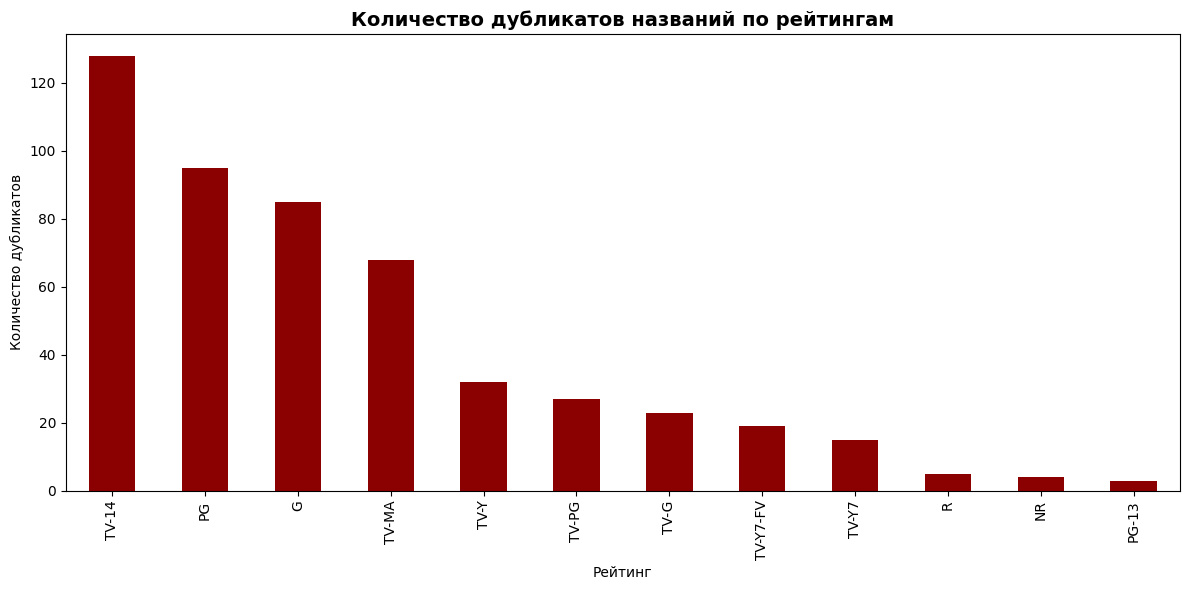

In [116]:
duplicates_by_rating = start_data[start_data.duplicated('title')].groupby('rating').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
duplicates_by_rating.plot(kind='bar', color='darkred')
plt.title('Количество дубликатов названий по рейтингам', fontsize=14, fontweight='bold')
plt.xlabel('Рейтинг')
plt.ylabel('Количество дубликатов')
plt.tight_layout()
plt.show()



Сколько рейтинговых групп представлено в данных?

13

In [117]:
start_data['rating'].nunique()


13

Какие оценки пользователи ставят чаще?

Постройте гистограмму оценок.
Почему именно такие оценки ставят чаще всего?

<Axes: xlabel='averageRating', ylabel='Count'>

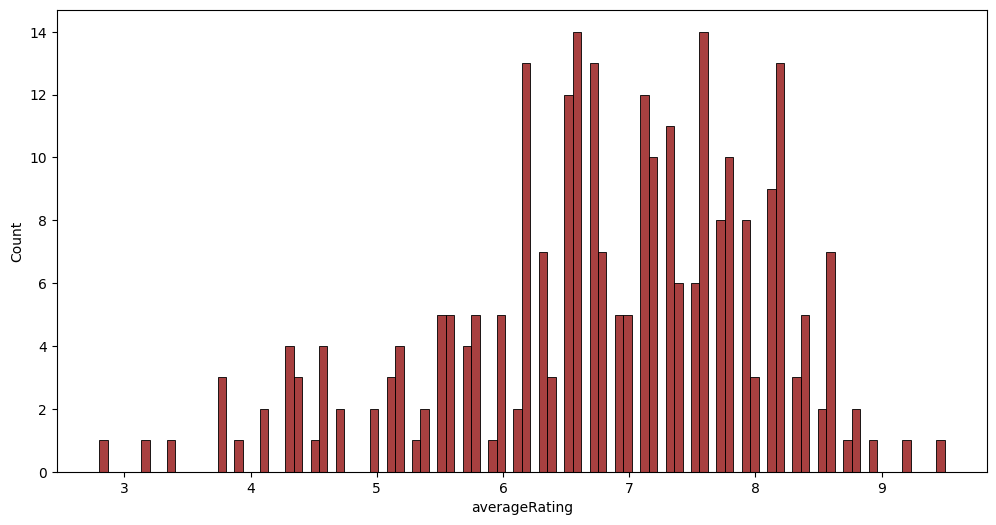

In [118]:
plt.figure(figsize=(12, 6))
sns.histplot(data=extra_data_countries, x='averageRating',color='darkred',  bins=100)

Большинство зрителей оценивают фильмы от 6 до 8. Люди редко оценивают что-то слишком низко 0-4 или слишком высоко 8-10. К тому же любят оценивать что-либо чуть выше среднего. Получившаяся картина довольно типична и логична

Выведите основную информацию об оценках пользователей

Чему равны среднее, стандартное отклонение, минимум, максимум, медиана?
Отличаются ли медиана и среднее?
Могут ли данные характеристики значительно отличаться? Почему?

In [119]:
extra_data_countries['averageRating'].describe()

,averageRating
count,274.000000
mean,6.822263
std,1.217748
min,2.800000
25%,6.200000
50%,7.000000
75%,7.700000
max,9.500000


In [120]:
extra_data_countries['averageRating'].median()

7.0

В данном случае медиана и среднее отличаются не сильно всего на 0.02. Однако если бы оценки фильмов сильно разделились на очень плохие или очень хорошие, то медиана попала бы на одну из сторон. В то время как среднее оставалось бы посередине.

In [121]:
extra_data_countries['release year'].min()

1978

In [122]:
extra_data_countries['release year'].max()

2017

Постройте график, показывающий распределение количества запущенных шоу в зависимости от года.

* Наблюдается ли рост?
* Есть ли выбросы?
* Что из себя представляют выбросы?
* Чем могут быть они вызваны?

<Axes: xlabel='release year', ylabel='Count'>

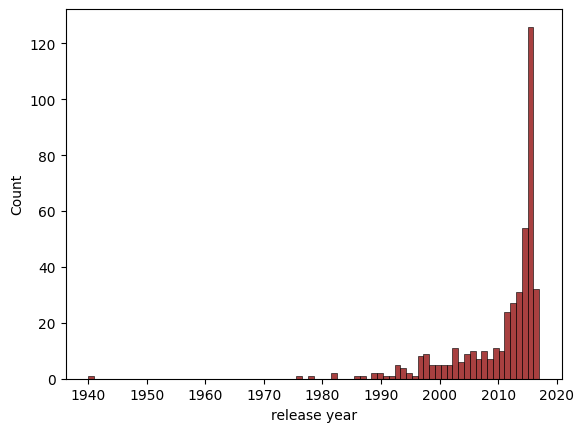

In [123]:
sns.histplot(data=main_data, x='release year',color='darkred',  bins=2017-1940+1)


- Рост наблюдается
- Виден выброс в 1940 году
- Выброс - сильно большое или сильно малое значение, однако важно, что возможное (хоть и маловероятное)
- Выброс может быть вызван маловероятным событием
- Уменьшение числа фильмов в 2017 году обсуловлено тем, что сбор данных происходил как раз в 2017 году, и еще не все фильмы были выпущены

Рассмотрим график без выброса:

(1975.0, 2017.0)

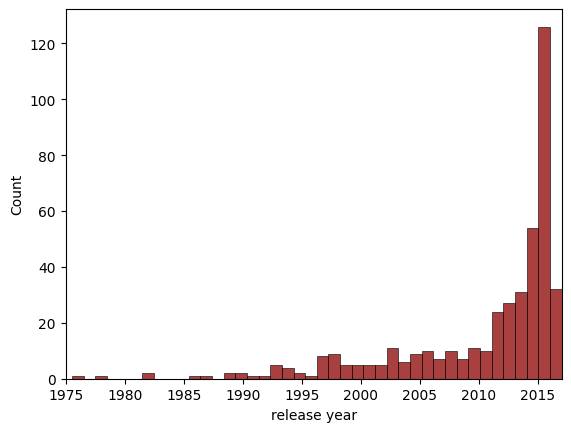

In [125]:
sns.histplot(data=main_data, x='release year',color='darkred',  bins=2017-1940+1)
plt.xlim(1975, 2017)


Сравните среднюю оценку пользователей в 2016 со средней оценкой в 2017.

- Можно ли сделать вывод, что 2017 год успешнее для Netflix? ("Успешнее" значит, что пользователи в среднем ставили более высокие оценки)
- Как еще можно оценить "Успешность"?

In [126]:
print(extra_data_countries[extra_data_countries['release year'] == 2016]['averageRating'].mean())
print(extra_data_countries[extra_data_countries['release year'] == 2017]['averageRating'].mean())

6.818965517241377
7.034375


- Нетфликс не обязательно стал лучше, если средняя оценка увеличилась. Так как могло получиться из-за того, что фильмы получаются либо очень плохие,
 либо очень хорошие и из-за этого нет средних фильмов, а средняя увеличилсь
- Успешность можно измерять по долям фильмов с низкой оценкой, условно ниже 70 и высокой условно выше 90

Расспределение фильмов по рейтингу лучше иллюстрировать через столбчатую диаграмму.

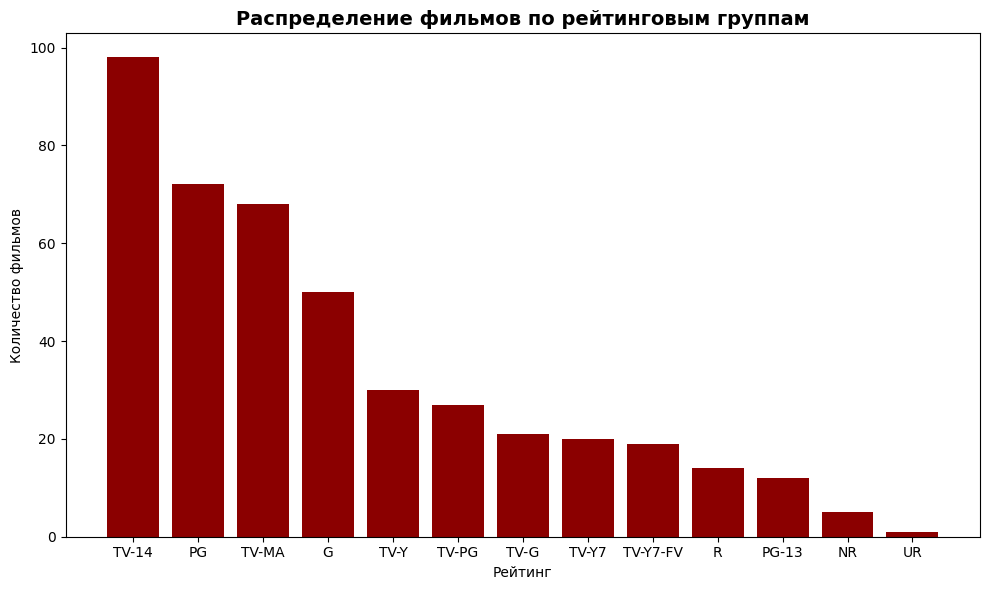

In [128]:
rating_distribution = main_data['rating'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(rating_distribution.index, rating_distribution.values, color='darkred')
plt.xlabel('Рейтинг')
plt.ylabel('Количество фильмов')
plt.title('Распределение фильмов по рейтинговым группам', fontsize=14, fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Чтобы разобраться, что же такое юзер рейтинг скор, посмотрим на его связь с ИМДБ (на ее отсутствие)

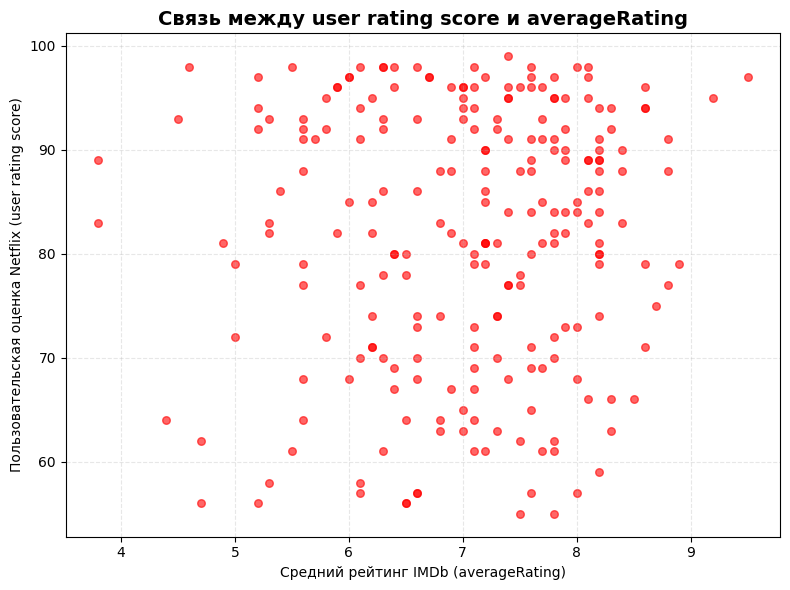

In [162]:
df = main_data

plt.figure(figsize=(8,6))
plt.scatter(df["averageRating"], df["user rating score"], color="red", s=30, alpha=0.6)

plt.title("Связь между user rating score и averageRating", fontsize=14, fontweight="bold")
plt.xlabel("Средний рейтинг IMDb (averageRating)")
plt.ylabel("Пользовательская оценка Netflix (user rating score)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Отображение средней длительности каждого жанра

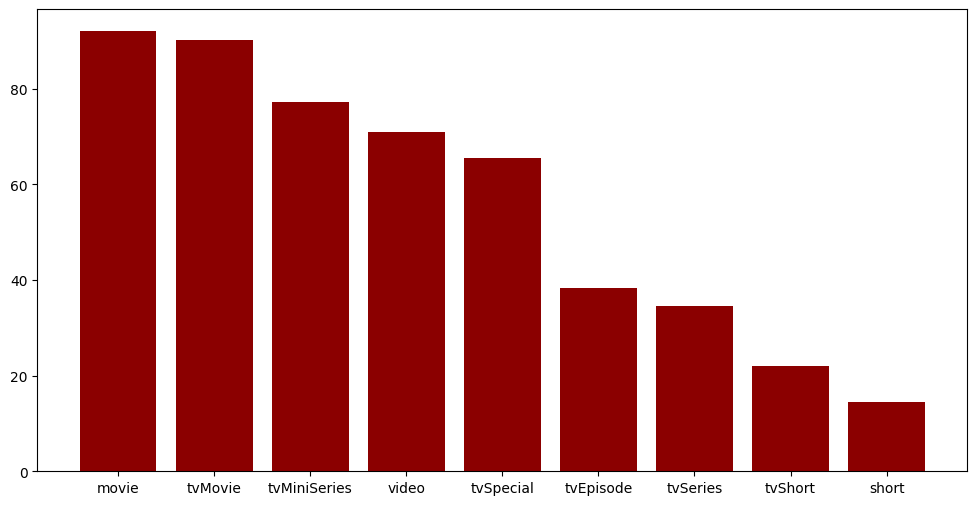

In [131]:
temp_data = main_data[main_data['runtimeMinutes'] != '']
temp_data['runtimeMinutes'] = pd.to_numeric(temp_data['runtimeMinutes'], errors='coerce')
mean_duration = temp_data.groupby('titleType')['runtimeMinutes'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
bars = plt.bar(mean_duration.index, mean_duration.values, color='darkred')

Зависимость рейтинга фильмов от времени показа

<Axes: xlabel='runtimeMinutes', ylabel='averageRating'>

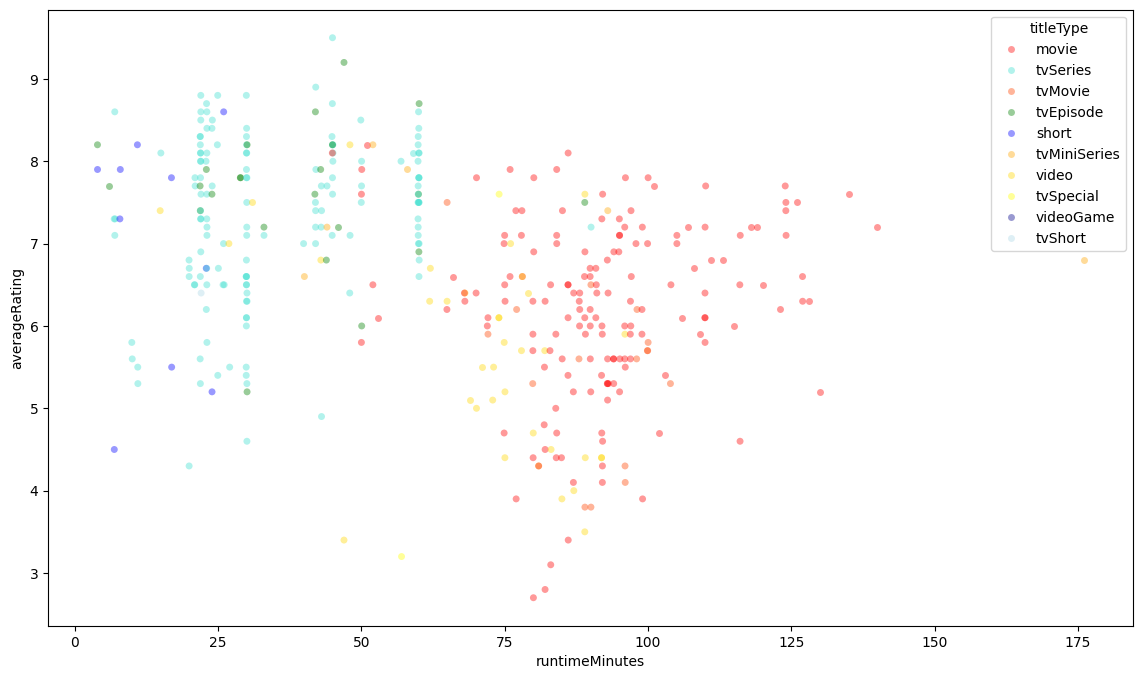

In [133]:
plt.figure(figsize=(14, 8))
temp_data = main_data[main_data['runtimeMinutes'] != ''].copy()
temp_data['runtimeMinutes'] = pd.to_numeric(temp_data['runtimeMinutes'], errors='coerce')
sns.stripplot(x='runtimeMinutes', y='averageRating', data=temp_data, hue='titleType',
              palette={'movie': 'red',
                       'tvMovie': 'orangered',
                       'video': 'gold',
                       'short': 'blue',
                       'tvSpecial': 'yellow',
                       'tvEpisode': 'green',
                       'tvShort': 'lightblue',
                       'tvSeries': 'turquoise',
                       'tvMiniSeries': 'orange',
                       'videoGame': 'darkblue'},
               alpha=0.4,native_scale=1)



- Заметно, что более короткий (холодный) тип материала оценивается лучше, чем длинный (теплый)
- Однако видно и то, что сериалы (более холодные цвета) с большим хронометражом чаще лучше оцениваются, так же и с фильмами (более теплые цвета)
- Абсолютное большинство сериалов короче 60 минут
- Желтые точки (tvSeries) начинают падать с увеличением времени

Уровень средних оценок по фильмам выпущенных странами

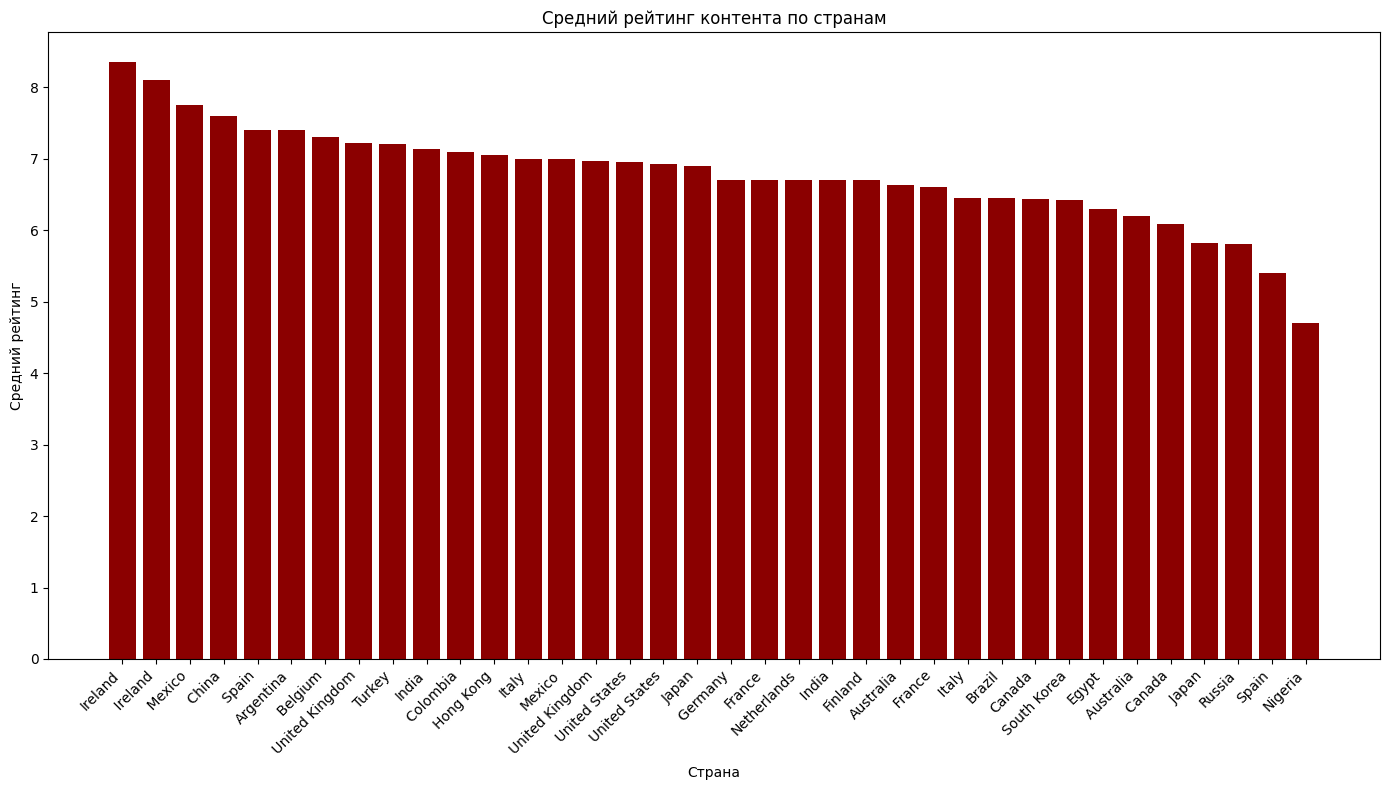

In [134]:
rating_data =extra_data_countries.dropna(subset=['country', 'averageRating'])

mean_rating = rating_data.groupby('country')['averageRating'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
bars = plt.bar(mean_rating.index, mean_rating.values, color='Darkred')

plt.title('Средний рейтинг контента по странам')
plt.xlabel('Страна')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [135]:
mean_rating = extra_data_countries.groupby('country')['averageRating'].mean().reset_index()

fig = px.choropleth(mean_rating,
                    locations='country',
                    locationmode='country names',
                    color='averageRating',
                    color_continuous_scale='Reds',
                    title='Средний рейтинг контента по странам')
fig.show()

Динамика распределения фильмов по жанрам по годам

In [136]:
df = (main_data
      .melt(id_vars=['release year'], value_vars=['genre_1','genre_2','genre_3'], value_name='genre')
      .dropna(subset=['genre'])
      .groupby(['release year','genre']).size().reset_index(name='count'))

df = df[df['release year'] >= sorted(df['release year'].unique())[-13]]
order = df.groupby('genre')['count'].mean().sort_values(ascending=False).index
colors = {
    genre: px.colors.qualitative.Plotly[i % len(px.colors.qualitative.Plotly)]
    for i, genre in enumerate(order)}

fig = px.bar(df, x='genre', y='count', color='genre', animation_frame='release year',
             category_orders={'genre': order},
             range_y=[0, df['count'].max()*1.1],
             title='Количество фильмов по жанрам за последние 13 лет')

fig.update_layout(
    showlegend=False, xaxis_title='Жанр', yaxis_title='Количество фильмов',
    transition={'duration':1000},
    updatemenus=[{
        'buttons':[{'args':[None,{'frame':{'duration':1600,'redraw':True},
                                  'transition':{'duration':800}}]},
                   {'args':[[None],{'frame':{'duration':0,'redraw':True}}]}]}])

fig.show()




Визуализация количества фильмов по жанрам выпущенных разными страннами

In [137]:
df = (extra_data_countries
      .melt(id_vars=['release year','country'], value_vars=['genre_1','genre_2','genre_3'], value_name='genre')
      .dropna(subset=['genre']))

counts = df.groupby(['country','genre']).size().reset_index(name='count')
fig = px.scatter(counts,x='country',y='genre',size='count',color='genre',hover_data=['count'],title='Количество фильмов по странам и жанрам')

fig.update_layout(
    xaxis_title='Страна',
    yaxis_title='Жанр',
)

fig.show()



США производит большую часть фильмов, из-за чего проблематично рассмотреть отношения остальных стран с жанрами. Запомним, что США - лидер и рассмотрим еще 1 график без США

In [138]:
df = (extra_data_countries
      .melt(id_vars=['release year','country'], value_vars=['genre_1','genre_2','genre_3'], value_name='genre')
      .dropna(subset=['genre']))

counts = df.groupby(['country','genre']).size().reset_index(name='count')
counts = counts[counts['country'] != 'United States']
fig = px.scatter(counts,x='country',y='genre',size='count',color='genre',hover_data=['count'],title='Количество фильмов по странам (без США) и жанрам')

fig.update_layout(
    xaxis_title='Страна',
    yaxis_title='Жанр',
)

fig.show()

Adventure и Comedy — часто встречаются среди крупных кругов, что говорит об их глобальной популярности. Это универсальные жанры, пользующиеся спросом во многих странах.

In [139]:
main = main_data

In [140]:
red_palette = [
    '#FF6B6B', '#FF5252', '#FF4040', '#FF2D2D', '#FF1A1A',
    '#FF0000', '#E60000', '#CC0000', '#B30000', '#990000',
    '#800000', '#660000', '#4D0000', '#330000', '#1A0000'
]

Рассмотрим распределение тайтлов по типу контента

In [141]:
type_counts = main['titleType'].value_counts()

red_reversed = red_palette[::-1]

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=type_counts.index,
    y=type_counts.values,
    marker_color=red_reversed[:len(type_counts)],
    text=type_counts.values,
    textposition='outside',
    textfont=dict(
        size=12,
        color='black')
))

fig1.update_layout(
    title='Распределение по типам контента',
    xaxis_title='Тип контента',
    yaxis_title='Количество',
    template='plotly_white',
    xaxis={'categoryorder':'total descending'}
)

fig1.update_yaxes(range=[0, type_counts.max() + 20])

fig1.show()

Можем объединить часть категорий к Фильмам и сериалам, тогда эти категории будут основными.

К фильмам можем отнести еще tvmovie,

К сериалам можем отнести еще tvseries, tvminiseries, tvepisode, tvspecial.

Рассмотрим их распределение по рейтингу

In [143]:
df = main

m = {
    'movie': 'Movie',
    'tvmovie': 'Movie',
    'tvseries': 'Series',
    'tvminiseries': 'Series',
    'tvepisode': 'Series',
    'tvspecial': 'Series'
}
df['Content'] = df['titleType'].str.lower().map(m)
df = df[df['Content'].isin(['Movie', 'Series'])]
df['averageRating'] = pd.to_numeric(df['averageRating'])

type_counts = (
    df['Content']
    .value_counts()
    .rename_axis('Content')
    .reset_index(name='count')
)
fig1 = px.bar(
    type_counts,
    x='Content', y='count',
    color='Content',
    color_discrete_map={'Movie': '#E50914', 'Series': '#4C4C4C'},
    title='Распределение по типу',
    template='plotly_white'
)
fig1.update_layout(showlegend=False)
fig1.show()

fig2 = px.box(
    df,
    x='Content', y='averageRating',
    color='Content',
    points='all',
    category_orders={'Content': ['Movie', 'Series']},
    color_discrete_map={'Movie': '#E50914', 'Series': '#4C4C4C'},
    title='Рейтинги: Movie vs Series',
    template='plotly_white'
)
fig2.update_layout(showlegend=False)
fig2.show()

/tmp/ipython-input-62303389.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



В среднем сериалы на нетфликс имеют большую среднюю оценку чем фильмы - Бизнесу при прочих равных стоит делать упор на создание/покупку сериалов, а не фильмов.

Рассмотрим, зависит ли рейтинг тайтла от его возрастной категории. Рассмотрим, как менялись средние рейтинги 10 самых многочисленных категорий по годам.

In [144]:

movie_data  = main
movie_data = movie_data.dropna(subset=['release year', 'averageRating', 'rating'])
movie_data['release year'] = movie_data['release year'].astype(int)

top_ratings = movie_data['rating'].value_counts().head(10).index.tolist()
movie_data = movie_data[movie_data['rating'].isin(top_ratings)]

all_years = sorted(movie_data['release year'].unique())
all_ratings = top_ratings

multi_index = pd.MultiIndex.from_product([all_years, all_ratings], names=['release year', 'rating'])
full_grid = pd.DataFrame(index=multi_index).reset_index()


yearly_rating_avg = movie_data.groupby(['release year', 'rating'])['averageRating'].mean().reset_index()


yearly_rating_counts = movie_data.groupby(['release year', 'rating']).size().reset_index(name='movie_count')

full_yearly_ratings = pd.merge(left=full_grid, right=yearly_rating_avg, on=['release year', 'rating'], how='left')
full_yearly_ratings = pd.merge(left=full_yearly_ratings, right=yearly_rating_counts, on=['release year', 'rating'],
                               how='left')

full_yearly_ratings['averageRating'] = full_yearly_ratings['averageRating'].fillna(0)
full_yearly_ratings['movie_count'] = full_yearly_ratings['movie_count'].fillna(0)


fig = px.bar(
    full_yearly_ratings,
    x='rating',
    y='averageRating',
    color='rating',
    animation_frame='release year',
    title='Средний рейтинг IMDb возрастных рейтингов по годам',
    labels={
        'rating': 'Возрастной рейтинг',
        'averageRating': 'Средний рейтинг IMDb',
        'release year': 'Год'
    },
    color_discrete_sequence=red_palette,
    height=600
)

fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 500
fig.layout.sliders[0].currentvalue.prefix = "Год: "

fig.update_traces(
    hovertemplate="<br>".join([
        "<b>%{x}</b>",
        "Средний рейтинг IMDb: %{y:.2f}",
        "<extra></extra>"
    ])
)


fig.update_layout(
    template='plotly_white',
    xaxis_title='Возрастной рейтинг',
    yaxis_title='Средний рейтинг IMDb',
    showlegend=False,
    xaxis={'categoryorder': 'array', 'categoryarray': all_ratings}
)

rating_max = full_yearly_ratings['averageRating'].max()
fig.update_yaxes(range=[0, rating_max + 2])

fig.show()

Мы легко можем оценить, какие возрастные ограничения были оценены выше в каждый год, однако изменение среднего рейтинга конкретного возрастного ограничения с течением времени затруднительно. Рассмотрим отдельные графики:

In [149]:
movie_data = main
movie_data = movie_data.dropna(subset=['release year', 'averageRating', 'rating'])
movie_data['release year'] = movie_data['release year'].astype(int)


top_ratings = movie_data['rating'].value_counts().head(10).index.tolist()
movie_data = movie_data[movie_data['rating'].isin(top_ratings)]


yearly_rating_avg = movie_data.groupby(['release year', 'rating'])['averageRating'].mean().reset_index()


fig = make_subplots(
    rows=5, cols=2,
    subplot_titles=top_ratings,
    vertical_spacing=0.08,
    horizontal_spacing=0.08
)


for i, rating in enumerate(top_ratings):
    row = (i // 2) + 1
    col = (i % 2) + 1

    rating_data = yearly_rating_avg[yearly_rating_avg['rating'] == rating]
    rating_data = rating_data.sort_values('release year')

    if len(rating_data) > 1:
        x = rating_data['release year'].values
        y = rating_data['averageRating'].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        trend_line = p(x)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=trend_line,
                mode='lines',
                line=dict(color='darkgrey', width=2, dash='dash'),
                showlegend=False,
                name=f'{rating} тренд'
            ),
            row=row, col=col
        )

    fig.add_trace(
        go.Scatter(
            x=rating_data['release year'],
            y=rating_data['averageRating'],
            mode='lines+markers',
            line=dict(color=red_palette[i], width=3),
            marker=dict(size=6, color=red_palette[i]),
            name=rating,
            hovertemplate=(
                f"<b>{rating}</b><br>" +
                "Год: %{x}<br>" +
                "Рейтинг: %{y:.2f}<br>" +
                "<extra></extra>"
            )
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text='Динамика среднего рейтинга IMDb по возрастным рейтингам',
    template='plotly_white',
    height=1200,
    showlegend=False
)

for i in range(1, 11):
    fig.update_xaxes(title_text='Год', row=(i+1)//2, col=((i-1)%2)+1)
    fig.update_yaxes(title_text='Рейтинг', row=(i+1)//2, col=((i-1)%2)+1)

fig.update_layout(
    title={
        'text': "Динамика среднего рейтинга IMDb возрастных рейтингов по годам",
        'y':0.99,
        'x':0.5
    }
)

fig.show()

Можем заметить, что рейтинг каждого из возрастного ограничения меняется практически хаотично. Из этого можем сделать вывод, что расчитывать на успех шоу только из-за его ограничения аудитории в долгосрочной перспективе - нельзя.

Наша следующая гипотеза заключается в том, что рейтинг может зависеть от жанра тайтла. Рассмотрим топ 15 самых многочисленных жанров.

In [150]:
all_genres = pd.concat([main['genre_1'], main['genre_2'], main['genre_3']])
all_genres = all_genres[all_genres != '']

genre_counts = all_genres.value_counts().head(15)
genre_counts = genre_counts.sort_values(ascending=True)

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=genre_counts.values,
    y=genre_counts.index,
    orientation='h',
    marker_color='#B20710',
    text=genre_counts.values,
    textposition='auto',
))


fig2.update_layout(
    title='Топ-15 самых популярных жанров',
    xaxis_title='Количество',
    yaxis_title='Жанр',
    template='plotly_white',
    height=500
)

fig2.show()

Среди тайтлов всех типов самыми популярными жанрами являются комедии и драмы. посмотрим распределение еще и по двум основным типам тайтлов

In [153]:
g = df[['Content', 'genre_1', 'genre_2', 'genre_3']].copy()
g = g.melt(
    id_vars='Content',
    value_vars=['genre_1', 'genre_2', 'genre_3'],
    value_name='genre'
).dropna(subset=['genre'])
g['genre'] = g['genre'].astype(str).str.strip()
g = g[g['genre'] != '']

top = g['genre'].value_counts().head(15).sort_values()
top_df = top.reset_index()
top_df.columns = ['genre', 'count']

stack_df = g[g['genre'].isin(top_df['genre'])]
ct = stack_df.groupby(['genre', 'Content']).size().reset_index(name='count')

fig4 = px.bar(
    ct,
    x='genre', y='count',
    color='Content',
    barmode='stack',
    color_discrete_map={'Movie': '#E50914', 'Series': '#4C4C4C'},
    title='Жанры внутри типов (топ-15)',
    template='plotly_white'
)
fig4.update_layout(xaxis_tickangle=-30)
fig4.show()

Рассмотрим, как менялись средние рейтинги жанров с течением **времени**

In [155]:

movie_data = main
movie_data = movie_data.dropna(subset=['release year', 'averageRating'])
movie_data['release year'] = movie_data['release year'].astype(int)


genres_list = []
for idx, row in movie_data.iterrows():
    genres = [row['genre_1']]
    if pd.notna(row['genre_2']) and row['genre_2'] != '':
        genres.append(row['genre_2'])
    if pd.notna(row['genre_3']) and row['genre_3'] != '':
        genres.append(row['genre_3'])

    for genre in genres:
        if genre != '' and pd.notna(genre):
            genres_list.append({
                'title': row['title'],
                'release year': row['release year'],
                'averageRating': row['averageRating'],
                'genre': genre
            })

genre_data = pd.DataFrame(genres_list)


top_genres = genre_data['genre'].value_counts().head(10).index.tolist()
genre_data = genre_data[genre_data['genre'].isin(top_genres)]

all_years = sorted(genre_data['release year'].unique())
all_genres = top_genres

multi_index = pd.MultiIndex.from_product([all_years, all_genres], names=['release year', 'genre'])
full_grid = pd.DataFrame(index=multi_index).reset_index()


yearly_genre_ratings = genre_data.groupby(['release year', 'genre'])['averageRating'].mean().reset_index()


full_yearly_ratings = pd.merge(full_grid, yearly_genre_ratings, on=['release year', 'genre'], how='left')

full_yearly_ratings['averageRating'] = full_yearly_ratings['averageRating'].fillna(0)


fig = px.bar(
    full_yearly_ratings,
    x='genre',
    y='averageRating',
    color='genre',
    animation_frame='release year',
    title='Изменение средних рейтингов самых многочисленных жанров по годам',
    labels={
        'genre': 'Жанр',
        'averageRating': 'Средний рейтинг IMDb',
        'release year': 'Год'
    },
    color_discrete_sequence=red_palette,
    height=600
)


fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 500
fig.layout.sliders[0].currentvalue.prefix = "Год: "

fig.update_layout(
    template='plotly_white',
    xaxis_title='Жанр',
    yaxis_title='Средний рейтинг IMDb',
    showlegend=False,
    xaxis={'categoryorder': 'array', 'categoryarray': top_genres}
)

fig.update_yaxes(range=[0, full_yearly_ratings['averageRating'].max() * 1.1])

fig.show()

Данный график позволяет нам быстро рассмотреть средние рейтинги самых многочисленных жанров в каждый момент времени с 1940 по 2017 год. Однако, можем заметить, что рейтинги нестабильны и постоянно меняются. Сложно выделить постоянный рост/снижение рейтинга отдельных жанров динамике, так как не во все годы выпускались фильмы всех жанров. Тогда рассмотрим графики изменения рейтинга жанров по отдельности.

In [156]:
movie_data = main
movie_data = movie_data.dropna(subset=['release year', 'averageRating'])
movie_data['release year'] = movie_data['release year'].astype(int)

all_genres = pd.concat([
    movie_data['genre_1'],
    movie_data['genre_2'],
    movie_data['genre_3']
]).dropna()

top_genres = all_genres.value_counts().head(10).index.tolist()

fig = make_subplots(
    rows=5, cols=2,
    subplot_titles=top_genres,
    vertical_spacing=0.08,
    horizontal_spacing=0.08
)

for i, genre in enumerate(top_genres):
    row = (i // 2) + 1
    col = (i % 2) + 1

    genre_movies = movie_data[
        (movie_data['genre_1'] == genre) |
        (movie_data['genre_2'] == genre) |
        (movie_data['genre_3'] == genre)
    ]

    yearly_genre_avg = genre_movies.groupby('release year')['averageRating'].mean().reset_index()
    yearly_genre_avg = yearly_genre_avg.sort_values('release year')

    if len(yearly_genre_avg) > 1:
        x = yearly_genre_avg['release year'].values
        y = yearly_genre_avg['averageRating'].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        trend_line = p(x)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=trend_line,
                mode='lines',
                line=dict(color='darkgrey', width=2, dash='dash'),
                showlegend=False,
                name=f'{genre} тренд'
            ),
            row=row, col=col
        )

    fig.add_trace(
        go.Scatter(
            x=yearly_genre_avg['release year'],
            y=yearly_genre_avg['averageRating'],
            mode='lines+markers',
            line=dict(color=red_palette[i], width=3),
            marker=dict(size=6, color=red_palette[i]),
            name=genre,
            hovertemplate=(
                f"<b>{genre}</b><br>" +
                "Год: %{x}<br>" +
                "Рейтинг: %{y:.2f}<br>" +
                "<extra></extra>"
            )
        ),
        row=row, col=col
    )

fig.update_layout(
    template='plotly_white',
    height=1200,
    showlegend=False,
    title={
        'text': "Динамика среднего рейтинга IMDb по жанрам",
        'y': 0.99,
        'x': 0.5
    }
)

for i in range(1, 11):
    fig.update_xaxes(title_text='Год', row=(i+1)//2, col=((i-1)%2)+1)
    fig.update_yaxes(title_text='Рейтинг', row=(i+1)//2, col=((i-1)%2)+1)

fig.show()

Действительно, по большей части рейтинг жанров меняется хаотично, однако в последние 3 года наблюдается тенденция на рост среднего рейтинга тайтлов жанров Animation, Adventure, Family и Action.

Т.к. они входят в топ 10 самых многочисленных жанров и наблюдается тенденция роста их среднего рейтинга, компания может рассмотреть возможность продвижения и рекомендации тайтлов этих жанров пользователям.

Рассмотрим теперь распределение среднего рейтинга IMDB в топ 15 жанров по численности (в остальных представлено слишком мало данных, чтобы отслеживать общие тенденции)

In [157]:
new_data_titles = main

genres_list = []
for idx, row in new_data_titles.iterrows():
    if pd.isna(row['averageRating']):
        continue

    genres = [row['genre_1']]
    if pd.notna(row['genre_2']) and row['genre_2'] != '':
        genres.append(row['genre_2'])
    if pd.notna(row['genre_3']) and row['genre_3'] != '':
        genres.append(row['genre_3'])

    for genre in genres:
        if genre != '' and pd.notna(genre):
            genres_list.append({
                'title': row['title'],
                'averageRating': row['averageRating'],
                'genre': genre
            })

genre_data = pd.DataFrame(genres_list)
genre_counts = genre_data['genre'].value_counts().head(15)
top_genres = genre_counts.index.tolist()
genre_data_top = genre_data[genre_data['genre'].isin(top_genres)]

median_rating = genre_data_top['averageRating'].median()


fig = px.violin(
    genre_data_top,
    x='genre',
    y='averageRating',
    color='genre',
    title='Распределение рейтингов IMDb по жанрам',
    labels={
        'genre': 'Genre',
        'averageRating': 'IMDb rating'
    },
    category_orders={'genre': top_genres},
    color_discrete_sequence=red_palette,
    box=True,
    points='all',
    hover_data=['title'],
    height=600
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Genre',
    yaxis_title='IMDb rating',
    showlegend=True,
    xaxis={'categoryorder': 'array', 'categoryarray': top_genres},
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01,
        bordercolor="Black",
        borderwidth=1
    )
)

fig.add_hline(
    y= median_rating,
    line_dash="dash",
    line_color="blue",
    line_width=2
)

fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode='lines',
        line=dict(dash='dash', color='blue', width=2),
        name=f'Медиана: {median_rating:.1f}',
        showlegend=True
    )
)


fig.show()

Можем заметить, что у немногочисленных жанров (например, Документальные тайтлы), достаточно часто встречается высокий средний рейтинг). Для компании было бы выгодно разместить больше тайтлов таких жанров. Возьмем и рассмотрим отдельно для фильмов и сериалов сопоставление жанров с самым высоким средним рейтингом, к числу фильмов/сериалов, им обладающих.

In [161]:
agg = (
    g.groupby('genre', as_index=False)
      .agg(count=('averageRating', 'size'), avg=('averageRating', 'mean'))
      .sort_values('avg', ascending=False)
)

fig = go.Figure()

fig.add_trace(go.Bar(
    y=agg['genre'],
    x=-agg['avg'],
    orientation='h',
    name='Средний рейтинг',
    marker_color='#E50914'
))
fig.add_trace(go.Bar(
    y=agg['genre'],
    x=agg['count'],
    orientation='h',
    name='Количество фильмов',
    marker_color='#222222'
))

fig.update_layout(
    title='Количество vs Средний рейтинг по жанрам',
    barmode='overlay',
    template='plotly_white',
    xaxis_title='',
    yaxis_title='Жанр',
    legend=dict(orientation='h', yanchor='bottom', y=-0.2, xanchor='center', x=0.5)
)
fig.show()


Из данного графика видно: что такие жанры как например History,Biography,Documentary в среднем нравятся зрителям больше чем остальные жанры, но кол-во таких фильмов не велико. Потенциально Netflix может купить права на такие фильмы, расширить свой ассортимент и сделать зрителей счастливее.

In [160]:
df = main
df['averageRating'] = pd.to_numeric(df['averageRating'])

m = {'movie':'Movie','tvmovie':'Movie','tvseries':'Series','tvminiseries':'Series','tvepisode':'Series','tvspecial':'Series'}
df['Content'] = df['titleType'].str.lower().map(m)
df = df[df['Content'].eq('Series')]

g = df[['averageRating','genre_1','genre_2','genre_3']].melt(id_vars=['averageRating'], value_name='genre').dropna(subset=['genre'])
g['genre'] = g['genre'].astype(str).str.strip()
g = g[~g['genre'].isin(['', r'\N', '\\N'])]

agg = (
    g.groupby('genre', as_index=False)
     .agg(count=('genre','size'), avg=('averageRating','mean'))
     .sort_values('avg', ascending=False)
)


plot = agg.copy()
plot['avg_n'] = plot['avg']
plot['cnt_n'] = plot['count']

fig = go.Figure()

fig.add_trace(go.Bar(
    y=plot['genre'],
    x=-plot['avg_n'],
    orientation='h',
    name='Средний рейтинг',
    marker_color='#E50914',
    customdata=np.stack([plot['avg'] , plot['count']], axis=1),
    hovertemplate='Жанр: %{y}<br>Средний рейтинг: %{customdata[0]:.2f}<br>Количество: %{customdata[1]}<extra></extra>'
))

fig.add_trace(go.Bar(
    y=plot['genre'],
    x=plot['cnt_n'],
    orientation='h',
    name='Количество тайтлов',
    marker_color='#4C4C4C',
    customdata=np.stack([plot['avg'] , plot['count']], axis=1),
    hovertemplate='Жанр: %{y}<br>Средний рейтинг: %{customdata[0]:.2f}<br>Количество: %{customdata[1]}<extra></extra>'
))

fig.update_layout(
    title='Сериалы: средние оценки и количество сериалов по жанрам',
    template='plotly_white',
    barmode='overlay',
    xaxis=dict(title='', showgrid=False, zeroline=True),
    yaxis=dict(title='Жанр'),
    legend=dict(orientation='h', yanchor='bottom', y=-0.12, xanchor='center', x=0.5),
    margin=dict(l=80, r=30, t=60, b=60)
)

fig.show()

С сериалами похожая картина: такие жанры как Biograpy,Sci-Fi имеют высокие отзывы но при этом коллекция таких фильмов не высокая. Бизнесу стоит задуматься над инвестициями в эти направлениях, т.к именно они потенциально могут принести наибольшую отдачу инвестициям.

В каестве дополнительных исследований рассмотрим еще несколько взаимосвязей

/tmp/ipython-input-311821712.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




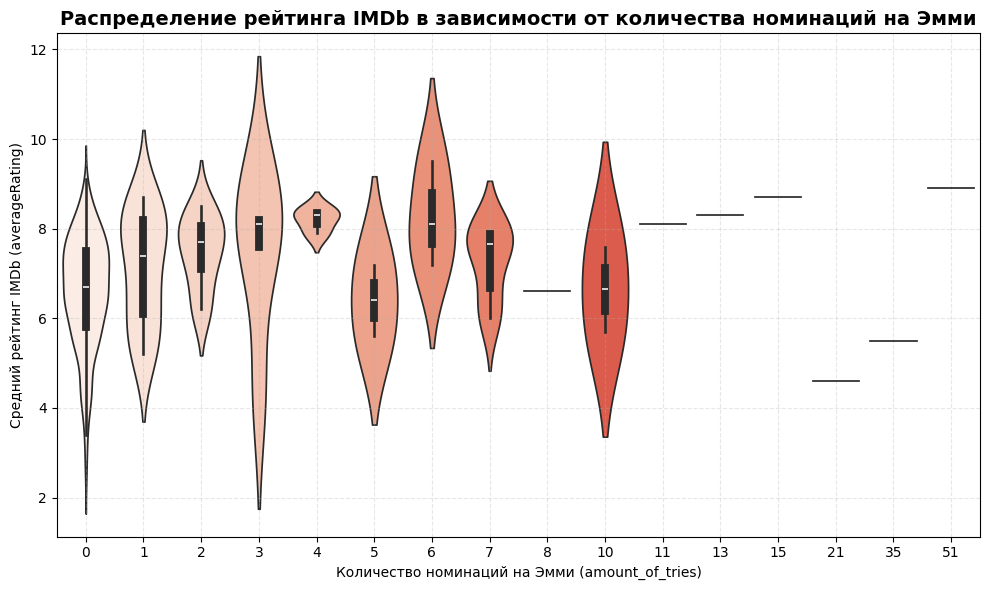

In [163]:
df = main
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="amount_of_tries", y="averageRating", palette="Reds", inner="box")

plt.title("Распределение рейтинга IMDb в зависимости от количества номинаций на Эмми", fontsize=14, fontweight="bold")
plt.xlabel("Количество номинаций на Эмми (amount_of_tries)")
plt.ylabel("Средний рейтинг IMDb (averageRating)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2320875708.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




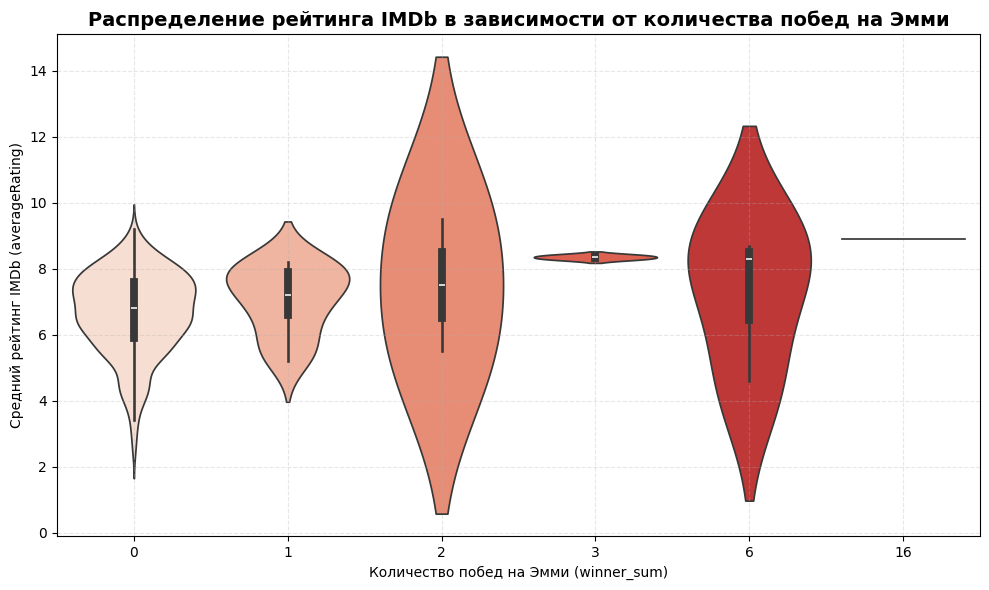

In [164]:
df = main
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="winner_sum", y="averageRating", palette="Reds", inner="box")

plt.title("Распределение рейтинга IMDb в зависимости от количества побед на Эмми", fontsize=14, fontweight="bold")
plt.xlabel("Количество побед на Эмми (winner_sum)")
plt.ylabel("Средний рейтинг IMDb (averageRating)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1522012074.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




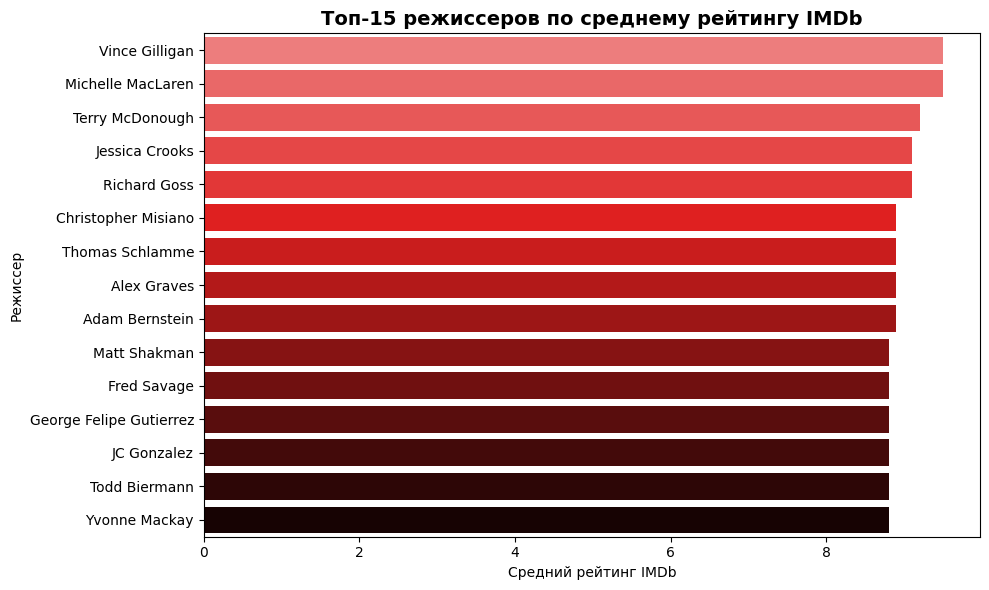

In [165]:
df = director_name_clean
df = df.dropna(subset=["primaryName", "averageRating"])
avg_rating = df.groupby("primaryName")["averageRating"].mean().reset_index()
top15 = avg_rating.sort_values(by="averageRating", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="averageRating", y="primaryName", data=top15, palette= red_palette)

plt.title("Топ-15 режиссеров по среднему рейтингу IMDb", fontsize=14, fontweight="bold")
plt.xlabel("Средний рейтинг IMDb")
plt.ylabel("Режиссер")
plt.tight_layout()
plt.show()